In [1]:
import joblib
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, predictions)

    return mae, rmse, r2

In [2]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = joblib.load(
    "../models/regression_data.pkl"
)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = joblib.load(
    "../models/classification_data.pkl"
)

In [3]:
linear_model = LinearRegression()

linear_model.fit(X_train_reg, y_train_reg)

linear_pred = linear_model.predict(X_test_reg)

In [4]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

tree_model.fit(X_train_reg, y_train_reg)

tree_pred = tree_model.predict(X_test_reg)

In [5]:
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(
    X_train_reg,
    y_train_reg
)

forest_pred = forest_model.predict(X_test_reg)

In [12]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)

    mse = mean_squared_error(y_true, predictions)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, predictions)

    return mae, rmse, r2

In [13]:
linear_result = regression_metrics(
    y_test_reg,
    linear_pred
)

tree_result = regression_metrics(
    y_test_reg,
    tree_pred
)

forest_result = regression_metrics(
    y_test_reg,
    forest_pred
)

In [14]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        linear_result[0],
        tree_result[0],
        forest_result[0]
    ],

    "RMSE": [
        linear_result[1],
        tree_result[1],
        forest_result[1]
    ],

    "R2 Score": [
        linear_result[2],
        tree_result[2],
        forest_result[2]
    ]
})

print(regression_results)

               Model        MAE       RMSE  R2 Score
0  Linear Regression  31.118656  57.931467  0.640969
1      Decision Tree  21.317815  28.883170  0.910753
2      Random Forest  15.932651  20.878950  0.953364


In [15]:
logistic = LogisticRegression(
    max_iter=1000
)

logistic.fit(
    X_train_cls,
    y_train_cls
)

logistic_pred = logistic.predict(
    X_test_cls
)

c:\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
tree_classifier = DecisionTreeClassifier(
    random_state=42
)

tree_classifier.fit(
    X_train_cls,
    y_train_cls
)

tree_pred_cls = tree_classifier.predict(
    X_test_cls
)

In [17]:
forest_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_classifier.fit(
    X_train_cls,
    y_train_cls
)

forest_pred_cls = forest_classifier.predict(
    X_test_cls
)

In [18]:
forest_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_classifier.fit(
    X_train_cls,
    y_train_cls
)

forest_pred_cls = forest_classifier.predict(
    X_test_cls
)

In [19]:
def classification_metrics(
    y_true,
    predictions
):
    accuracy = accuracy_score(
        y_true,
        predictions
    )

    precision = precision_score(
        y_true,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        predictions,
        average="weighted"
    )

    return accuracy, precision, recall, f1

In [20]:
logistic_result = classification_metrics(
    y_test_cls,
    logistic_pred
)

tree_result_cls = classification_metrics(
    y_test_cls,
    tree_pred_cls
)

forest_result_cls = classification_metrics(
    y_test_cls,
    forest_pred_cls
)

In [21]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_result[0],
        tree_result_cls[0],
        forest_result_cls[0]
    ],

    "Precision": [
        logistic_result[1],
        tree_result_cls[1],
        forest_result_cls[1]
    ],

    "Recall": [
        logistic_result[2],
        tree_result_cls[2],
        forest_result_cls[2]
    ],

    "F1 Score": [
        logistic_result[3],
        tree_result_cls[3],
        forest_result_cls[3]
    ]
})

print(classification_results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.808076   0.786415  0.808076  0.796301
1        Decision Tree  1.000000   1.000000  1.000000  1.000000
2        Random Forest  0.995724   0.995767  0.995724  0.995576


In [22]:
cm = confusion_matrix(
    y_test_cls,
    forest_pred_cls
)

print(cm)

[[796   0   0   0   0   0]
 [  0  56   4   3   2   0]
 [  0   0 357   0   0   0]
 [  0   0   0 278   0   0]
 [  0   0   0   0 279   0]
 [  0   0   0   0   0 330]]


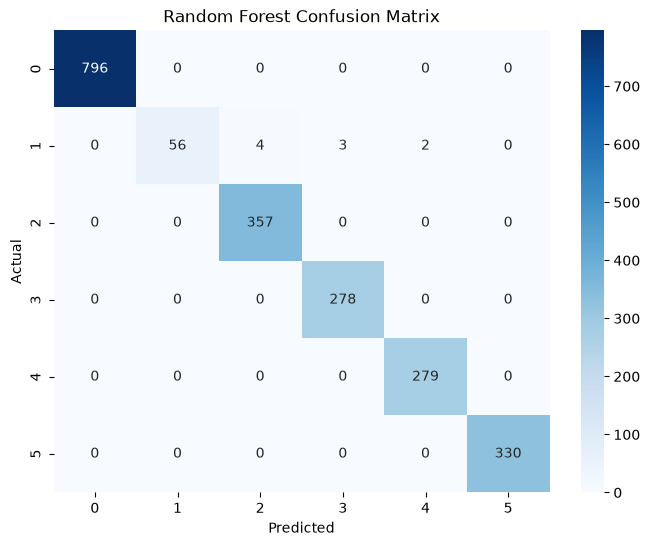

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
joblib.dump(
    forest_model,
    "../models/best_regression_model.pkl"
)

joblib.dump(
    forest_classifier,
    "../models/best_classification_model.pkl"
)

['../models/best_classification_model.pkl']